# Floor bias (over-zero) from the DuckDB warehouse

Runs the deployed floor-bias model against `data/cfb.duckdb` instead of the
`data/raw/lines_*.json` replay log, and reconciles the two sources game by game.

**Why.** The raw JSON files get backfilled in place and their mtimes do not track
their content — refreshing `ROI_HITRATE.md` on 2026-09-22 moved every historical
season's row by a total of +793 graded games with no code change
(`docs/roi-refresh-backfill-2026-09-22.md`). `data/cfb.duckdb` is the repo's
stated source of truth, so it is worth knowing whether it reproduces the result.

**Outcome.** The warehouse is now the model's default source — every
`monitor/` entry point takes `--source` and defaults to `warehouse`. This
notebook is the evidence behind that switch and the way to re-check it. The
write-up is `docs/warehouse-as-model-source-2026-09-22.md`.

Nothing here writes to `docs/`. In particular it never touches
`docs/backtest_bets.csv`, which `roi_report.py` owns.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# models/over_zero is the unit root; v2/ and monitor/ are not packages, so both
# go on sys.path explicitly. `import monitor` would otherwise resolve to the
# directory as a namespace package and fail.
UNIT = Path.cwd()
if UNIT.name == "notebooks":
    UNIT = UNIT.parent
sys.path[:0] = [str(UNIT / "v2"), str(UNIT / "monitor")]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import models_v2
import roi_report
import roi_hitrate_doc
from warehouse_source import load_warehouse_frame, load_warehouse_seasons

SEASONS = list(range(2013, 2027))
MIN_TRAIN = 3            # matches the deployed walk-forward
THRESHOLD = 1.75         # the deployed filter
pd.set_option("display.width", 140)

print(f"unit root: {UNIT}")
print(f"warehouse: {models_v2.RAW_DIR.parent / 'cfb.duckdb'}")

unit root: C:\Users\mckel\dev\cfb\models\over_zero
warehouse: C:\Users\mckel\dev\cfb\data\cfb.duckdb


## 2. Load from the warehouse

`core.fact_game.selected_spread` / `selected_total` is the warehouse analogue of
`models_v2.pick_line`: consensus provider first, else a book carrying both
numbers. Same favourite convention (negative spread = home favoured), same
pick'em drop.

In [2]:
wh = load_warehouse_frame(SEASONS)
wh_data = load_warehouse_seasons(SEASONS)

print(f"{len(wh):,} gradeable games, {wh.season.nunique()} seasons")
wh.head()

13,397 gradeable games, 14 seasons


,game_id,season,week,start_date,home_team,away_team,spread,total,spread_provider,total_provider,home_points,away_points
0,332412579,2013,1,2013-08-29 18:00:00-04:00,South Carolina,North Carolina,-11.5,56.0,consensus,teamrankings,27,10
1,332410135,2013,1,2013-08-29 19:00:00-04:00,Minnesota,UNLV,-17.0,52.0,consensus,teamrankings,51,23
2,332410189,2013,1,2013-08-29 19:00:00-04:00,Bowling Green,Tulsa,3.0,50.5,consensus,teamrankings,34,7
3,332412116,2013,1,2013-08-29 19:00:00-04:00,UCF,Akron,-28.0,55.5,consensus,teamrankings,38,7
4,332410254,2013,1,2013-08-29 20:00:00-04:00,Utah,Utah State,-4.5,52.0,consensus,teamrankings,30,26


In [3]:
(wh.assign(combined=wh.home_points + wh.away_points)
   .groupby("season")
   .agg(games=("game_id", "size"),
        mean_spread=("spread", lambda s: s.abs().mean()),
        mean_total=("total", "mean"),
        mean_combined=("combined", "mean"))
   .round(2))

,games,mean_spread,mean_total,mean_combined
season,,,,
2013,737,12.14,56.61,56.87
2014,760,10.91,56.42,56.90
2015,765,11.22,56.32,56.97
2016,759,11.48,57.08,58.08
2017,781,11.74,56.13,55.94
2018,849,13.40,56.68,57.17
2019,880,14.03,55.95,55.90
2020,567,12.29,56.88,57.57
2021,887,13.63,55.67,55.19


## 3. Reconcile against the raw JSON

Two questions: which games does each source have that the other does not, and
where the two overlap, do they agree on the line?

In [4]:
def raw_frame(seasons):
    """Same selection rule as models_v2.load_raw_seasons, but keeping game ids."""
    import json
    rows = []
    for season in seasons:
        path = models_v2.RAW_DIR / f"lines_{season}.json"
        if not path.exists():
            continue
        for g in json.loads(path.read_text(encoding="utf-8")):
            hp, ap = g.get("homeScore"), g.get("awayScore")
            if hp is None or ap is None:
                continue
            picked = models_v2.pick_line(g, None)
            if picked is None:
                continue
            spread, total = picked
            if spread == 0:
                continue
            rows.append({"game_id": int(g["id"]), "season": int(season),
                         "spread": float(spread), "total": float(total),
                         "home_points": float(hp), "away_points": float(ap)})
    return pd.DataFrame(rows)


rw = raw_frame(SEASONS)
print(f"raw: {len(rw):,} gradeable games   warehouse: {len(wh):,}")

raw: 13,402 gradeable games   warehouse: 13,397


In [5]:
counts = (pd.concat([
    wh.groupby("season").size().rename("warehouse"),
    rw.groupby("season").size().rename("raw"),
], axis=1).fillna(0).astype(int))
counts["diff"] = counts.warehouse - counts.raw
counts.loc["TOTAL"] = counts.sum()
counts

,warehouse,raw,diff
season,,,
2013,737,737,0
2014,760,757,3
2015,765,762,3
2016,759,760,-1
2017,781,784,-3
2018,849,851,-2
2019,880,881,-1
2020,567,567,0
2021,887,887,0


In [6]:
wh_ids, rw_ids = set(wh.game_id), set(rw.game_id)
only_wh, only_rw = wh_ids - rw_ids, rw_ids - wh_ids
print(f"in warehouse only: {len(only_wh):,}")
print(f"in raw only:       {len(only_rw):,}")
print(f"shared:            {len(wh_ids & rw_ids):,}")

by_season = lambda ids, df: (df[df.game_id.isin(ids)].groupby("season").size()
                             if ids else pd.Series(dtype=int))
pd.concat([by_season(only_wh, wh).rename("warehouse_only"),
           by_season(only_rw, rw).rename("raw_only")], axis=1).fillna(0).astype(int)

in warehouse only: 6
in raw only:       11
shared:            13,391


,warehouse_only,raw_only
season,,
2014,3,0
2015,3,0
2016,0,1
2017,0,3
2018,0,2
2019,0,1
2023,0,3
2025,0,1


In [7]:
# Where both sources carry a game, do they pick the same numbers?
both = wh.merge(rw, on=["game_id", "season"], suffixes=("_wh", "_rw"))
both["d_spread"] = both.spread_wh - both.spread_rw
both["d_total"] = both.total_wh - both.total_rw
both["d_score"] = ((both.home_points_wh + both.away_points_wh)
                   - (both.home_points_rw + both.away_points_rw))

print(f"shared games: {len(both):,}")
for col in ("d_spread", "d_total", "d_score"):
    n = int((both[col].abs() > 1e-9).sum())
    print(f"  {col:9} differs on {n:5,} games ({n/len(both):6.2%})"
          + (f"   max |diff| {both[col].abs().max():.2f}" if n else ""))

shared games: 13,391
  d_spread  differs on 2,667 games (19.92%)   max |diff| 44.50
  d_total   differs on    11 games ( 0.08%)   max |diff| 2.00
  d_score   differs on     0 games ( 0.00%)


The spread disagreement is the one worth reading carefully. It is mostly ordinary
book-to-book variation, but the tail is not: a handful of games carry the same
`consensus` label in both sources and still disagree by 20+ points, including
exact sign flips. Those are not two books quoting different numbers — they are
the two sources disagreeing about which side is favoured.

In [8]:
d = both[both.d_spread.abs() > 1e-9]
print("|d_spread| on disagreeing games:")
print(d.d_spread.abs().describe(percentiles=[.5, .75, .9, .99]).round(2).to_string())

flips = int(((both.spread_wh + both.spread_rw).abs() < 1e-9).sum())
print(f"\nexact sign flips (same magnitude, opposite side): {flips}")
print(f"\nwarehouse provider when the spread differs:")
print(d.spread_provider.value_counts().head(5).to_string())

|d_spread| on disagreeing games:
count    2667.00
mean        2.44
std         2.26
min         0.50
50%         2.00
75%         3.25
90%         5.00
99%         9.17
max        44.50

exact sign flips (same magnitude, opposite side): 16

warehouse provider when the spread differs:
spread_provider
consensus     2624
draftkings      43


In [9]:
worst = d.reindex(d.d_spread.abs().sort_values(ascending=False).index)
worst[["game_id", "season", "home_team", "away_team",
       "spread_wh", "spread_rw", "spread_provider",
       "home_points_wh", "away_points_wh"]].head(10)

,game_id,season,home_team,away_team,spread_wh,spread_rw,spread_provider,home_points_wh,away_points_wh
1177,400550420,2014,Georgia Southern,Troy,20.5,-24.0,consensus,42,10
1694,400760494,2015,Penn State,Army,7.5,-25.0,consensus,20,14
706,333570151,2013,East Carolina,Ohio,-13.0,14.5,consensus,37,20
1525,400763407,2015,West Virginia,Georgia Southern,-38.0,-16.0,consensus,44,0
1866,400760496,2015,Rice,Army,14.0,-7.0,consensus,38,31
1497,400603839,2015,Vanderbilt,Western Kentucky,-17.5,2.5,consensus,12,14
1517,400763592,2015,Tulsa,Florida Atlantic,-21.0,-4.0,consensus,47,44
1506,400764855,2015,SMU,Baylor,20.0,36.0,consensus,21,56
2919,400869642,2016,Maryland,Rutgers,-2.0,-15.5,consensus,31,13
2506,400869125,2016,UCLA,Arizona,3.0,-10.5,consensus,45,24


In [10]:
disagree = both[both.d_total.abs() > 1e-9]
if len(disagree):
    display(disagree.groupby("season").agg(
        games=("game_id", "size"),
        mean_abs_total_diff=("d_total", lambda s: s.abs().mean().round(3)),
        max_abs_total_diff=("d_total", lambda s: s.abs().max()),
    ))
else:
    print("no total disagreements on shared games")

,games,mean_abs_total_diff,max_abs_total_diff
season,,,
2013,3,1.000,1.0
2014,1,2.000,2.0
2015,3,0.667,1.0
2016,1,1.000,1.0
2025,3,1.000,1.0


## 4. Walk-forward on the warehouse

Unchanged protocol: for season *t*, fit the Tobit sigmas + probit on seasons
< *t* only, then grade *t*. `warehouse_source` returns the same contract as
`load_raw_seasons`, so `roi_report.walk_forward_bets` runs untouched.

In [11]:
def run(data, label):
    years = sorted(data)
    season, bias, over, prob = roi_report.walk_forward_bets(
        data, years, MIN_TRAIN)[:4]
    sel = bias > THRESHOLD
    n, wins = int(sel.sum()), int(over[sel].sum())
    w = wins / n
    lo, hi = roi_report.wilson_roi(wins, n)
    print(f"{label:10}  N={n:4}  {wins}-{n-wins}  hit={w*100:6.2f}%  "
          f"ROI={roi_report.unit_roi(w)*100:+7.2f}%  95% [{lo*100:+.2f}, {hi*100:+.2f}]")
    return {"season": season, "bias": bias, "over": over, "sel": sel,
            "n": n, "wins": wins, "win": w, "roi": roi_report.unit_roi(w),
            "roi_lo": lo, "roi_hi": hi}


wh_res = run(wh_data, "warehouse")

warehouse   N= 274  177-97  hit= 64.60%  ROI= +23.32%  95% [+12.20, +33.68]


### By season

In [12]:
def season_rows(res):
    s_b, o_b, b_b = (res["season"][res["sel"]], res["over"][res["sel"]],
                     res["bias"][res["sel"]])
    yrs = sorted(set(s_b.tolist()))
    return roi_hitrate_doc.rows_for(b_b, o_b, yrs, [str(int(y)) for y in yrs],
                                    lambda t: s_b == t)


def as_frame(rows, keys=("label", "n", "wins", "losses", "win", "roi",
                         "roi_lo", "roi_hi", "clears")):
    df = pd.DataFrame([{k: r.get(k) for k in keys} for r in rows])
    for c in ("win", "roi", "roi_lo", "roi_hi"):
        df[c] = (df[c] * 100).round(2)
    return df


as_frame(season_rows(wh_res))

,label,n,wins,losses,win,roi,roi_lo,roi_hi,clears
0,2016,3,1,2,33.33,-36.36,-88.26,51.27,False
1,2017,8,5,3,62.50,19.32,-41.63,64.78,False
2,2018,16,12,4,75.00,43.18,-3.59,71.47,False
3,2019,16,13,3,81.25,55.11,8.80,78.33,True
4,2020,6,4,2,66.67,27.27,-42.73,72.43,False
5,2021,28,21,7,75.00,43.18,8.14,66.71,True
6,2022,37,22,15,59.46,13.51,-16.98,40.61,False
7,2023,41,28,13,68.29,30.38,1.21,53.56,True
8,2024,30,19,11,63.33,20.91,-13.11,49.15,False
9,2025,50,26,24,52.00,-0.73,-26.48,24.48,False


### By bias bin — the question the bands answer

In [13]:
def bin_rows(res):
    edges = list(zip(roi_hitrate_doc.BIN_EDGES[:-1], roi_hitrate_doc.BIN_EDGES[1:]))
    labels = [f"{lo:.2f}-{hi:.2f}" if np.isfinite(hi) else f">{lo:.2f}"
              for lo, hi in edges]
    return roi_hitrate_doc.rows_for(res["bias"], res["over"], edges, labels,
                                    lambda e: (res["bias"] > e[0]) & (res["bias"] <= e[1]))


wh_bins = bin_rows(wh_res)
as_frame(wh_bins)

,label,n,wins,losses,win,roi,roi_lo,roi_hi,clears
0,0.00-0.50,9112,4401,4711,48.30,-7.79,-9.75,-5.83,False
1,0.50-1.00,1159,606,553,52.29,-0.18,-5.68,5.29,False
2,1.00-1.75,492,261,231,53.05,1.27,-7.16,9.62,False
3,1.75-2.50,186,119,67,63.98,22.14,8.55,34.65,True
4,>2.50,88,58,30,65.91,25.83,6.00,43.11,True


## 5. Side by side with the raw-sourced run

The committed `docs/ROI_HITRATE.md` is the raw-sourced record. This re-runs it
here so the two are compared under identical code in one process.

In [14]:
rw_data = models_v2.load_raw_seasons(SEASONS, models_v2.RAW_DIR, None)
rw_res = run(rw_data, "raw")
rw_bins = bin_rows(rw_res)

cmp = (as_frame(wh_bins)[["label", "n", "win", "roi", "roi_lo", "roi_hi"]]
       .merge(as_frame(rw_bins)[["label", "n", "win", "roi", "roi_lo", "roi_hi"]],
              on="label", suffixes=("_wh", "_raw")))
cmp["roi_gap"] = (cmp.roi_wh - cmp.roi_raw).round(2)
cmp

raw         N= 275  178-97  hit= 64.73%  ROI= +23.57%  95% [+12.47, +33.90]


,label,n_wh,win_wh,roi_wh,roi_lo_wh,roi_hi_wh,n_raw,win_raw,roi_raw,roi_lo_raw,roi_hi_raw,roi_gap
0,0.00-0.50,9112,48.30,-7.79,-9.75,-5.83,9118,48.29,-7.81,-9.77,-5.85,0.02
1,0.50-1.00,1159,52.29,-0.18,-5.68,5.29,1157,52.55,0.32,-5.18,5.79,-0.50
2,1.00-1.75,492,53.05,1.27,-7.16,9.62,498,52.61,0.44,-7.94,8.74,0.83
3,1.75-2.50,186,63.98,22.14,8.55,34.65,185,63.78,21.77,8.14,34.33,0.37
4,>2.50,88,65.91,25.83,6.00,43.11,90,66.67,27.27,7.71,44.23,-1.44


In [15]:
pooled = pd.DataFrame([
    {"source": "warehouse", **{k: wh_res[k] for k in ("n", "wins", "win", "roi", "roi_lo", "roi_hi")}},
    {"source": "raw",       **{k: rw_res[k] for k in ("n", "wins", "win", "roi", "roi_lo", "roi_hi")}},
])
for c in ("win", "roi", "roi_lo", "roi_hi"):
    pooled[c] = (pooled[c] * 100).round(2)
pooled

,source,n,wins,win,roi,roi_lo,roi_hi
0,warehouse,274,177,64.60,23.32,12.20,33.68
1,raw,275,178,64.73,23.57,12.47,33.90


### ROI by bias bin, both sources

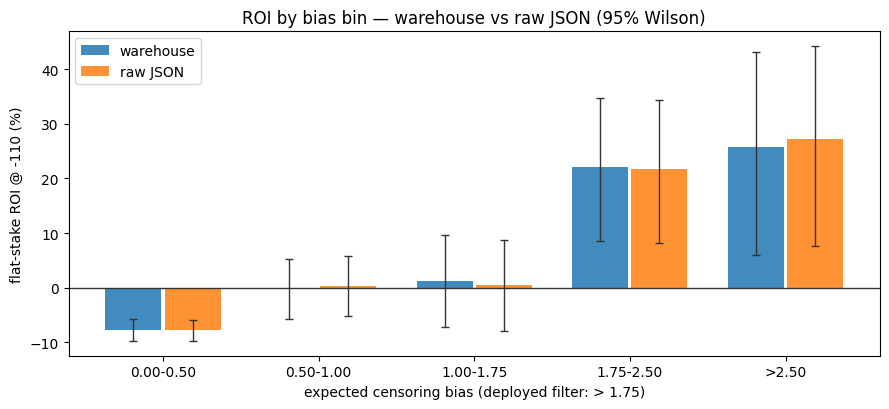

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(cmp))
for off, col, lo, hi, lab, c in ((-0.19, "roi_wh", "roi_lo_wh", "roi_hi_wh", "warehouse", "#1f77b4"),
                                 (0.19, "roi_raw", "roi_lo_raw", "roi_hi_raw", "raw JSON", "#ff7f0e")):
    err = np.vstack([cmp[col] - cmp[lo], cmp[hi] - cmp[col]])
    ax.bar(x + off, cmp[col], 0.36, label=lab, color=c, alpha=.85)
    ax.errorbar(x + off, cmp[col], yerr=err, fmt="none", ecolor="#333", lw=1, capsize=3)

ax.axhline(0, color="#333", lw=1)
ax.set_xticks(x); ax.set_xticklabels(cmp.label)
ax.set_xlabel(f"expected censoring bias (deployed filter: > {THRESHOLD})")
ax.set_ylabel("flat-stake ROI @ -110 (%)")
ax.set_title("ROI by bias bin — warehouse vs raw JSON (95% Wilson)")
ax.legend(); fig.tight_layout(); plt.show()

## 6. Three rules, one source question

The 19.92% spread gap is not corruption — both sources agree with their own
`formattedSpread` on every game. It is the selection rule. `pick_line` keeps only
providers carrying **both** a spread and a total, so a consensus spread published
without a consensus total is discarded and the model falls back to whatever book
the JSON listed first, usually a projection site. `core.fact_game` picks each
field independently and keeps the consensus spread.

So run three rules and see what the choice is worth.

In [17]:
from warehouse_source import load_warehouse_seasons as _lw

three = {
    "raw / pick_line":        rw_data,
    "warehouse / per-field":  wh_data,
    "warehouse / coherent":   _lw(SEASONS, coherent_pair=True),
}
for label, d in three.items():
    run(d, label)

raw / pick_line  N= 275  178-97  hit= 64.73%  ROI= +23.57%  95% [+12.47, +33.90]


warehouse / per-field  N= 274  177-97  hit= 64.60%  ROI= +23.32%  95% [+12.20, +33.68]
warehouse / coherent  N= 210  141-69  hit= 67.14%  ROI= +28.18%  95% [+15.56, +39.63]


In [18]:
PROJECTION = {"numberfire", "teamrankings"}

pair = load_warehouse_frame(SEASONS, coherent_pair=True)
mix = {"raw / pick_line": None, "warehouse / per-field": wh,
       "warehouse / coherent": pair}
for label, frame in mix.items():
    if frame is None:
        continue
    sp = frame.spread_provider.str.lower()
    tp = frame.total_provider.str.lower()
    print(f"{label:24} consensus spread {(sp=='consensus').mean():6.1%}   "
          f"projection spread {sp.isin(PROJECTION).mean():6.1%}   "
          f"projection EITHER field {(sp.isin(PROJECTION)|tp.isin(PROJECTION)).mean():6.1%}")

warehouse / per-field    consensus spread  60.0%   projection spread   1.5%   projection EITHER field  23.2%
warehouse / coherent     consensus spread  49.8%   projection spread   0.0%   projection EITHER field   0.0%


The coherent-pair run scores highest and is the one **not** to use. It applies
the same rule as `pick_line` and differs only in the tiebreak when no consensus
pair exists — JSON array order versus `order by provider_key`. Both land on a
projection site at the same ~23% rate; alphabetical order just lands on a
different one. The gap is an arbitrary `ORDER BY`, chosen after seeing it scored
better, which is the failure mode `docs/model-evaluation-standard.md` calls
invalidating.

The per-field rule ships: most consensus spreads, the warehouse's own published
selection rather than one invented here, and an ROI inside the raw path's
interval rather than above it.

Note the last column. The warehouse's low projection-site *spread* rate is not a
tradeability win — `selected_total` is projection-sourced on the same 23% of
games. On 99.7% of those no book in the feed published both numbers, so neither
rule could have been bet as priced. That is a CFBD coverage limit, not a
selection mistake.

## 7. What this does and does not show

- **Does show** whether the warehouse reproduces the raw-sourced walk-forward,
  and exactly which games and lines the two sources disagree on.
- **Does not re-grade the committed result.** `docs/ROI_HITRATE.md` stays the
  raw-sourced record. If the warehouse is adopted as the model's source, that is
  a separate change with its own write-up, and
  `docs/model-evaluation-standard.md` binds any ROI claim made from it.
- **No proper score here.** Hit rate, ROI and Wilson intervals only — no Brier
  or log-loss against the de-vigged market, which the evaluation standard asks
  for at Tier 1. That gap is inherited from the existing generators.
- **The threshold was chosen partly on this data**, so the pooled point estimate
  is inflated either way; the lower bound is the planning number.
- **2026 is partial** — weeks 1-3 only, so its row moves every week.

Nothing above wrote to `docs/`.